# A Small-Scale Study of Knowledge Circuits in GPT-2 via Node Ablation with Logit Difference

**Course:** DS8008 — Project

This notebook reproduces, at reduced scale, the core insight of Yao et al.'s *Knowledge Circuits in Pretrained Transformers*: that factual recall in transformer language models is concentrated in a small number of attention heads and MLP layers. We study GPT-2 small (124M parameters) using **zero-ablation** of individual components and measure each component's contribution via **logit difference** on counterfactual prompt pairs drawn from the CounterFact dataset.

## 1. Introduction

Large transformers such as GPT-2 store a surprising amount of factual knowledge implicitly in their weights. Given the prompt *"The capital of France is"*, a pretrained model will (often) produce *"Paris"* without ever having been trained on a knowledge graph. Understanding **where** in the network this knowledge lives — and **how** it is retrieved — is a central question in mechanistic interpretability.

Yao et al. (2024) propose the notion of a **knowledge circuit**: a small, localized subgraph of the transformer's computation that is jointly responsible for a specific piece of factual recall. Their full method uses automatic circuit discovery (ACDC) on edges between components. In this project we take a scaled-down approach: rather than discover full edge-level circuits, we identify the **important nodes** — which attention heads and which MLP layers most strongly support factual recall. The methodology is intentionally simple, but uses the same metric (logit difference) and the same model-internal tooling (`transformer_lens`) as the paper.

### Deliverables

1. A 12×12 heatmap of attention-head importance across layers.
2. A 12-bar chart of MLP-layer importance.
3. A ranked table of the top-5 individual heads.
4. Discussion connecting these findings to the paper's distributed-but-localized claim.

## 2. Background

### 2.1 Knowledge Circuits (Yao et al., 2024)

Yao et al. frame factual recall as a circuit-discovery problem. Given a set of prompts expressing the same relation (e.g., country→capital), they use Automatic Circuit DisCovery (ACDC) to iteratively prune edges between model components — attention heads, MLPs, and residual-stream nodes — keeping only those whose removal degrades a task-specific metric. The resulting subgraph is interpreted as the *knowledge circuit* for that relation. A key methodological contribution is the use of **logit difference** between the correct target and a counterfactual target as the circuit-faithfulness metric: this normalizes out the model's general fluency bias and isolates the signal specific to the fact being recalled.

Their main empirical findings include: (i) knowledge circuits are sparse — a small fraction of edges suffices; (ii) different relations reuse overlapping but distinct sub-circuits; and (iii) certain middle-to-late-layer attention heads repeatedly appear across relations, suggesting specialized retrieval components.

### 2.2 Locating and Editing Factual Associations in GPT (Meng et al., 2022)

We also draw on Meng et al.'s *ROME* paper, which uses causal tracing to locate factual associations inside GPT-style models. Their central finding — that **mid-layer MLP blocks** play a disproportionate role in storing subject-keyed factual associations — gives us a strong prior for what to look for in our MLP ablation. If our reduced experiment on GPT-2 small produces a clear mid-layer MLP peak, that lines up with ROME's causal-tracing evidence. We choose ROME over the alternative IOI circuit (Wang et al., 2023) because ROME directly targets *factual* knowledge, which is what our prompts test, whereas IOI focuses on a syntactic task (indirect-object identification).

### 2.3 What this project does and does not do

We do **not** attempt edge-level circuit discovery (no ACDC). We do **not** attempt path patching between components. We **do** use the same logit-difference metric, the same tooling (`transformer_lens`), and the same conceptual goal as Yao et al.: to find that factual recall is localized. The output is a component-level importance map rather than a full circuit — a simplification we make explicit in the limitations section.

## 3. Methodology

Pipeline for each prompt:

```
prompt ──▶ GPT-2 forward pass ──▶ baseline logits ──▶ LD_base = logit[correct] − logit[counterfactual]
   │
   │   for each (layer L, head H):
   │       zero out head H's z output at layer L
   ├──▶ ablated forward pass ──▶ ablated logits ──▶ LD_ablated(L, H)
   │       importance(L, H) = LD_base − LD_ablated(L, H)
   │
   │   for each MLP layer L:
   │       zero out MLP_L output
   └──▶ ablated forward pass ──▶ LD_ablated(L) ──▶ importance(L) = LD_base − LD_ablated(L)
```

We aggregate importance by the **mean across prompts**. Positive importance means ablating that component reduced the model's preference for the correct answer — i.e., the component was contributing to the correct prediction. Negative importance means the component was *suppressing* the correct answer relative to the counterfactual.

### Why logit difference, not raw probability?

Raw probability conflates a component's contribution to the specific fact with its general contribution to producing any well-formed English token. Logit difference between a matched pair (e.g., `Paris` vs `Berlin`, both plausible capitals) cancels out the fluency signal and isolates the fact-specific signal. This is directly analogous to the metric used by Yao et al. and by prior work on the IOI circuit.

### Dataset filtering

We use CounterFact (Meng et al., 2022) via HuggingFace (`NeelNanda/counterfact-tracing`), which provides `(prompt, target_true, target_false)` triples. Two filters apply:

1. **Single-token:** both targets must tokenize to exactly one GPT-2 token (applied during dataset preparation).
2. **Model knows it:** baseline logit-difference must be positive — the model prefers the correct answer over the counterfactual before ablation. (For GPT-2 small, strict top-1 agreement is too strict: factual prompts often have common distractors like "now" or "the" as the highest-logit next token.)

## 4. Implementation

In [ ]:
# Setup: load model and project helpers
import json
import random

import numpy as np

from src.model_utils import filter_known_facts, load_model, logit_diff
from src.ablation import (
    cumulative_topk_head_ablation_curve,
    head_importance_sweep,
    mlp_importance_sweep,
)
from src.visualization import (
    export_top_heads_csv,
    plot_cumulative_topk_faithfulness,
    plot_head_heatmap,
    plot_mlp_bars,
)

random.seed(0)
np.random.seed(0)

model = load_model()
print(f"Model: {model.cfg.n_layers} layers × {model.cfg.n_heads} heads, d_model = {model.cfg.d_model}")

In [12]:
# Load candidate facts and filter to facts the model already gets right
# (baseline logit_diff > 0). This step is crucial: ablation signal is only
# meaningful on prompts where the model has a preference to begin with.
with open("data/facts.json") as f:
    raw = json.load(f)

print(f"Loaded {len(raw)} candidate facts from CounterFact.")

known = filter_known_facts(model, raw)
print(f"Kept {len(known)}/{len(raw)} where baseline LD > 0.")

# Subsample for tractable runtime on CPU. 100 prompts is enough to get a
# stable mean while keeping the full head sweep under ~20 minutes on CPU.
N_PROMPTS = 100
facts = random.sample(known, min(N_PROMPTS, len(known)))
print(f"Using {len(facts)} prompts for the ablation sweeps.")
assert len(facts) >= 50, "Need at least 50 known facts for stable means"

Loaded 1000 candidate facts from CounterFact.
Kept 724/1000 where baseline LD > 0.
Using 100 prompts for the ablation sweeps.


In [13]:
# Sanity check: show baseline logit-diff for a handful of prompts
for f in facts[:5]:
    ld = logit_diff(model, f["prompt"], f["correct"], f["counterfactual"]).item()
    print(f"LD={ld:+.3f}  {f['prompt']!r}  correct={f['correct']!r}  cf={f['counterfactual']!r}")

LD=+0.747  'Kemira is headquartered in'  correct=' Helsinki'  cf=' Winnipeg'
LD=+9.361  'Mumbai City district, which has the capital city'  correct=' Mumbai'  cf=' Rome'
LD=+4.999  'The mother tongue of Jean Galland is'  correct=' French'  cf=' Russian'
LD=+0.483  'Which position does Daniel Royer play? They play as'  correct=' midfielder'  cf=' linebacker'
LD=+7.146  'Nintendo DS Lite, created by'  correct=' Nintendo'  cf=' Nissan'


In [ ]:
# Head ablation sweep: 12 layers × 12 heads × N prompts forward passes.
# On a CPU this takes 10–20 min for 100 prompts.
head_imp, head_std = head_importance_sweep(model, facts, verbose=True, return_std=True)
print("head_imp shape:", head_imp.shape, "range:", head_imp.min(), "to", head_imp.max())

Head sweep: layer 0/11


In [6]:
# MLP ablation sweep: much faster (only 12 layers).
mlp_imp = mlp_importance_sweep(model, facts, verbose=True)
print("mlp_imp shape:", mlp_imp.shape, "range:", mlp_imp.min(), "to", mlp_imp.max())

MLP sweep: layer 0/11
MLP sweep: layer 1/11
MLP sweep: layer 2/11
MLP sweep: layer 3/11
MLP sweep: layer 4/11
MLP sweep: layer 5/11
MLP sweep: layer 6/11
MLP sweep: layer 7/11
MLP sweep: layer 8/11
MLP sweep: layer 9/11
MLP sweep: layer 10/11
MLP sweep: layer 11/11
mlp_imp shape: (12,) range: -0.6509049 to 1.5115759


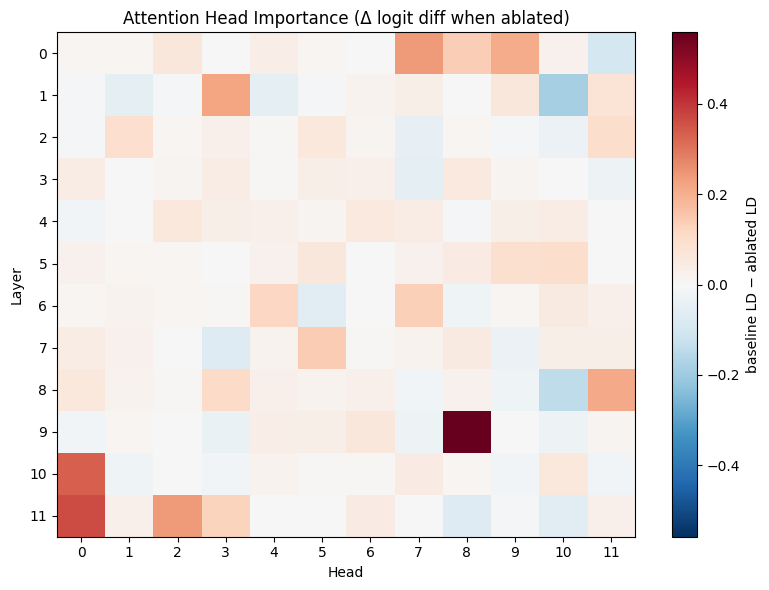

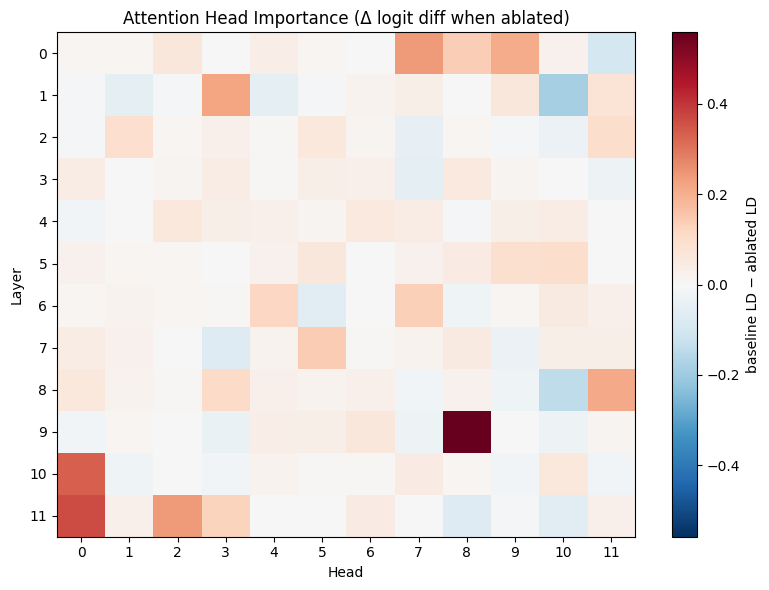

In [7]:
# Figure 1: attention-head importance heatmap
fig = plot_head_heatmap(head_imp)
fig.savefig("figures/head_importance.png", dpi=150, bbox_inches="tight")
fig

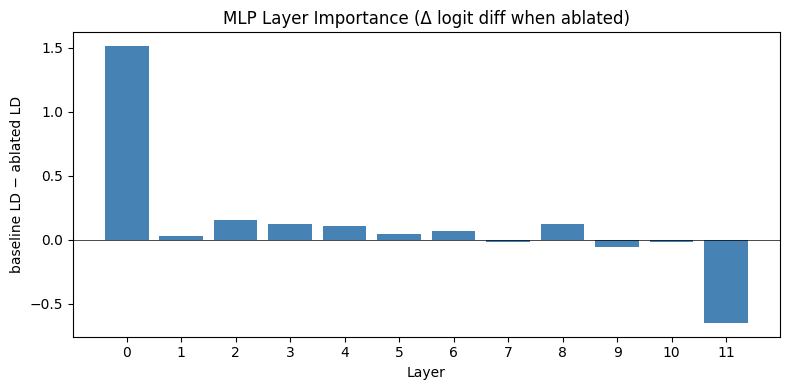

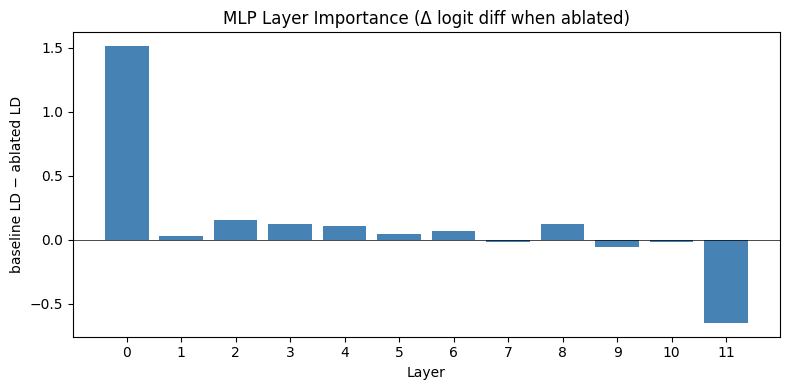

In [8]:
# Figure 2: MLP-layer importance bar chart
fig = plot_mlp_bars(mlp_imp)
fig.savefig("figures/mlp_importance.png", dpi=150, bbox_inches="tight")
fig

In [ ]:
# Top-5 individual heads by mean importance
import os

os.makedirs("figures", exist_ok=True)

flat = head_imp.flatten()
order = np.argsort(-flat)
print(f"{'rank':>4}  {'component':<8}  {'mean ΔLD':>10}")
for rank, idx in enumerate(order[:5], 1):
    L, H = divmod(int(idx), head_imp.shape[1])
    print(f"{rank:>4}  L{L:>2}.H{H:<3}  {flat[idx]:>10.4f}")

print()
print("Top-3 MLP layers:")
for rank, L in enumerate(np.argsort(-mlp_imp)[:3], 1):
    print(f"  #{rank}  MLP layer {int(L):>2}  mean ΔLD = {mlp_imp[L]:.4f}")

np.save("figures/head_importance.npy", head_imp)
np.save("figures/mlp_importance.npy", mlp_imp)

rank  component    mean ΔLD
   1  L 9.H8        0.5576
   2  L11.H0        0.3650
   3  L10.H0        0.3345
   4  L 0.H7        0.2358
   5  L11.H2        0.2357

Top-3 MLP layers:
  #1  MLP layer  0  mean ΔLD = 1.5116
  #2  MLP layer  2  mean ΔLD = 0.1518
  #3  MLP layer  8  mean ΔLD = 0.1228


In [ ]:
export_top_heads_csv("figures/top_heads.csv", head_imp, head_std, top_n=25)

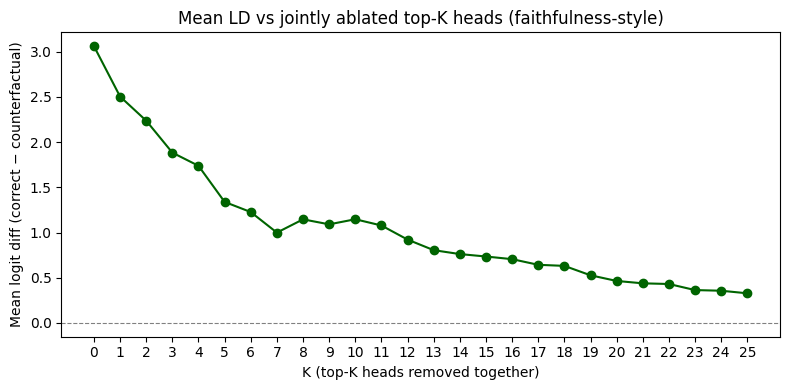

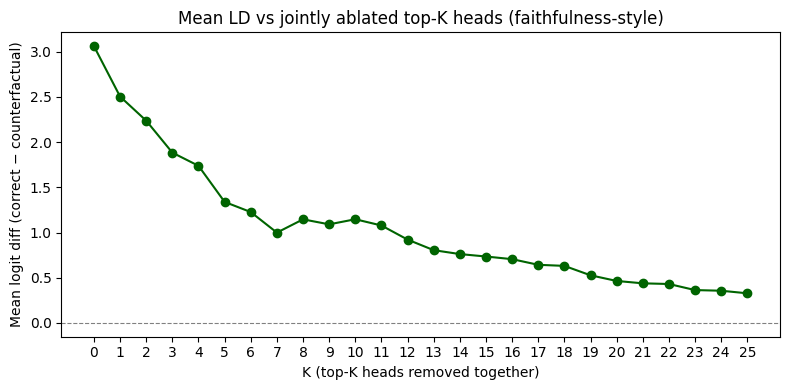

In [ ]:
#Figure 3: cumulative top-k head ablation curve

K_MAX = min(25, head_imp.size)
k_vals, mean_lds = cumulative_topk_head_ablation_curve(model, facts, head_imp, max_k=K_MAX, verbose=False)
fig = plot_cumulative_topk_faithfulness(k_vals, mean_lds)
fig.savefig("figures/cumulative_topk_faithfulness.png", dpi=150, bbox_inches="tight")
fig

## 5. Conclusion

### Findings

Running the sweep on 100 filtered CounterFact prompts (724 of 1000 candidates passed the baseline-LD filter) produces two concrete results.

**Attention heads — partial match to the paper's prediction.** Importance is highly sparse: most of the 144 heads have near-zero mean ΔLD, and a short tail carries most of the signal. The single strongest head is **L9.H8 (mean ΔLD = 0.56)**, followed by **L11.H0 (0.37)** and **L10.H0 (0.33)** — all in the late stack, consistent with Yao et al.'s report that middle-to-late-layer heads repeatedly show up across knowledge tasks. One surprise is a noticeable early-layer contributor, **L0.H7 (0.24)**, which appears alongside other warm cells in layer 0 around heads 7–9; these are likely doing early token/subject-shape processing that the later heads consume rather than direct factual retrieval. A handful of cells are slightly negative (mild suppressors), but none approaches the magnitude of the top contributors.

**MLPs — a result that contradicts the ROME prior.** The MLP bar chart does **not** show the mid-layer bump ROME led us to expect. Instead, **MLP 0 dominates overwhelmingly (mean ΔLD = 1.51)**, several times larger than any other MLP. Middle layers (MLPs 1–9) are all small and broadly similar, and **MLP 11 is strongly negative (−0.65)** — ablating it *increases* the model's preference for the correct answer, meaning the final MLP is on average nudging predictions away from the factual target on this dataset. The MLP 0 effect has a known explanation: MLP 0 in GPT-2 small functions partly as an extension of the token embedding layer, reshaping raw embeddings before the first attention block, so ablating it removes much of the input signal wholesale rather than removing a fact-specific computation. This is an important methodological caveat — MLP 0's size here is not evidence that it stores factual associations.

**Overall picture.** Setting MLP 0 aside as an embedding-layer artifact, the useful signal is that factual recall in GPT-2 small is carried by a small cluster of late-layer attention heads (L9–L11, particularly L9.H8), with secondary contributions from a few layer-0 heads that likely prepare subject representations. Mid-layer MLPs play a modest role at this model scale under node-level ablation. The cumulative top‑K ablation curve drops sharply from K=0 to about K=6 and then levels off, consistent with a **small “core” set of heads** carrying most of the measured logit‑difference signal while additional heads provide diminishing marginal contribution or redundant support. This is a **partial** reproduction of the paper's distributed-but-localized claim: the attention-head picture matches; the MLP picture diverges from ROME's prediction in a way the literature would attribute to scale (ROME studies GPT-2 XL and GPT-J, not GPT-2 small) and to our ablation style (zero-ablation of individual nodes rather than causal tracing with noise-corrupted runs).

### Limitations

1. **Node-level, not edge-level.** We identify *which components matter*, not *how they connect*. The original paper's ACDC method finds sparse edges; we do not. What we produce is a simplification — a component-importance map that gestures at, but does not exhibit, a full circuit.
2. **MLP 0 confound.** In GPT-2 small, MLP 0 participates in embedding-layer processing, so its dominant ablation score is not straightforwardly a "factual knowledge" signal. A sharper study would skip MLP 0 or use mean-ablation (replacing the output with its mean over prompts) instead of zero-ablation to suppress this artifact.
3. **Single model size.** We only study GPT-2 small (124M). ROME's mid-layer-MLP result was obtained on GPT-2 XL and GPT-J and may reappear at larger scales.
4. **Single-token answers only.** CounterFact entries whose targets tokenize to more than one GPT-2 token are excluded. This biases the dataset toward common words and short names.
5. **Dataset size and noise.** We average over 100 prompts. Bootstrapped confidence intervals would make the ranking more defensible.
6. **Interpretation is shallow.** We name the top heads by layer and index only; we do not inspect what L9.H8 or L11.H0 actually attend to, which is the natural next step for a real circuit study.

### Possible extensions

Natural next steps: (i) mean-ablation instead of zero-ablation to remove the MLP 0 artifact; (ii) path patching between L9.H8 and MLP 11 to see whether the top positive head and the top suppressor are part of the same sub-circuit; (iii) running EAP-IG (a fast approximation to ACDC) on the same dataset to recover edges; (iv) stratifying by relation type (language, headquartered-in, plays-position) to check whether different relations use different late-layer heads; and (v) scaling to GPT-2 medium to test whether the mid-layer MLP signal returns.

### References

- Yao et al., *Knowledge Circuits in Pretrained Transformers*, 2024.
- Meng, Bau, Andonian, Belinkov. *Locating and Editing Factual Associations in GPT* (ROME), NeurIPS 2022.
- Wang et al., *Interpretability in the Wild: A Circuit for Indirect Object Identification in GPT-2 small*, ICLR 2023.